In [7]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [8]:
TRAIN_DIR = "../data/train"
VAL_DIR = "../data/val"
TEST_DIR = "../data/test"

In [9]:
def count_images(folder_path):
    return len(os.listdir(folder_path))

In [57]:
train_normal = count_images(os.path.join(TRAIN_DIR, "NORMAL"))
train_pneumonia = count_images(os.path.join(TRAIN_DIR, "PNEUMONIA"))

val_normal = count_images(os.path.join(VAL_DIR, "NORMAL"))
val_pneumonia = count_images(os.path.join(VAL_DIR, "PNEUMONIA"))

test_normal = count_images(os.path.join(TEST_DIR, "NORMAL"))
test_pneumonia = count_images(os.path.join(TEST_DIR, "PNEUMONIA"))

In [56]:
import os

print("Train Normal :", len(os.listdir("../data/train/NORMAL")))
print("Train Pneumonia :", len(os.listdir("../data/train/PNEUMONIA")))

print("Val Normal :", len(os.listdir("../data/val/NORMAL")))
print("Val Pneumonia :", len(os.listdir("../data/val/PNEUMONIA")))

print("Test Normal :", len(os.listdir("../data/test/NORMAL")))
print("Test Pneumonia :", len(os.listdir("../data/test/PNEUMONIA")))

Train Normal : 1342
Train Pneumonia : 3876
Val Normal : 9
Val Pneumonia : 9
Test Normal : 234
Test Pneumonia : 390


In [58]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Train", "Train",
        "Validation", "Validation",
        "Test", "Test"
    ],
    "Class": [
        "NORMAL", "PNEUMONIA",
        "NORMAL", "PNEUMONIA",
        "NORMAL", "PNEUMONIA"
    ],
    "Count": [
        train_normal,
        train_pneumonia,
        val_normal,
        val_pneumonia,
        test_normal,
        test_pneumonia
    ]
})

dataset_summary

,Dataset,Class,Count
0,Train,NORMAL,1342
1,Train,PNEUMONIA,3876
2,Validation,NORMAL,9
3,Validation,PNEUMONIA,9
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


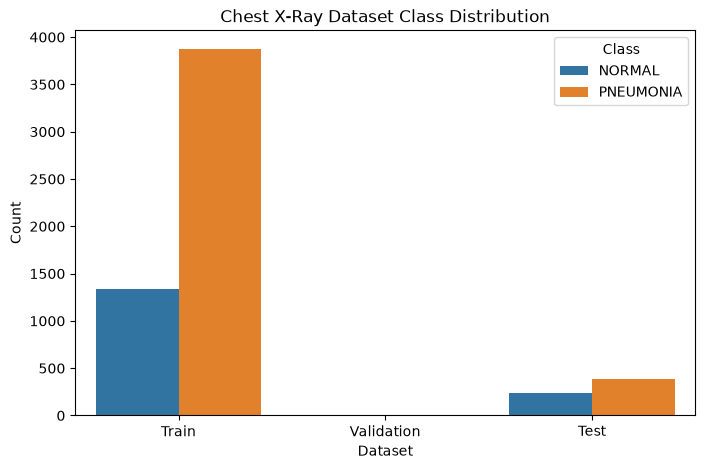

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_summary,
    x="Dataset",
    y="Count",
    hue="Class"
)

plt.title("Chest X-Ray Dataset Class Distribution")

plt.show()

In [61]:
normal_images = [
    img for img in os.listdir(
        os.path.join(TRAIN_DIR, "NORMAL")
    )
    if img.endswith((".jpeg", ".jpg", ".png"))
]

pneumonia_images = [
    img for img in os.listdir(
        os.path.join(TRAIN_DIR, "PNEUMONIA")
    )
    if img.endswith((".jpeg", ".jpg", ".png"))
]

print("Normal Images:", len(normal_images))
print("Pneumonia Images:", len(pneumonia_images))

Normal Images: 1341
Pneumonia Images: 3875


In [62]:
normal_path = os.path.join(
    TRAIN_DIR,
    "NORMAL",
    normal_images[0]
)

pneumonia_path = os.path.join(
    TRAIN_DIR,
    "PNEUMONIA",
    pneumonia_images[0]
)

print(normal_path)
print(pneumonia_path)

../data/train\NORMAL\IM-0115-0001.jpeg
../data/train\PNEUMONIA\person1000_bacteria_2931.jpeg


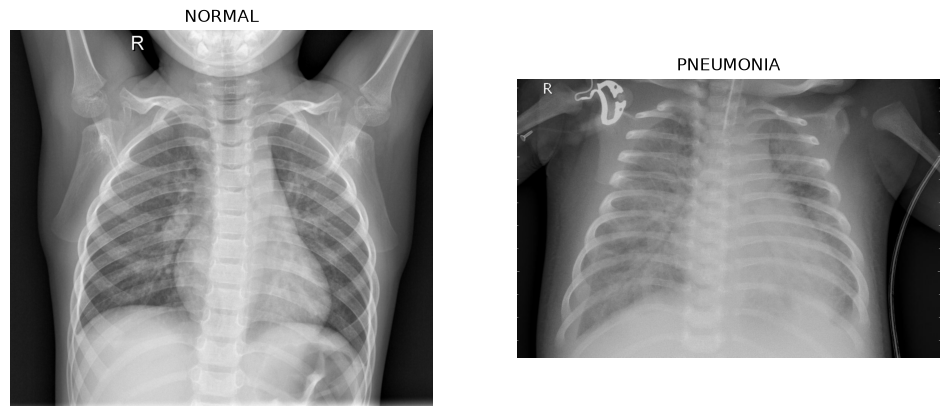

In [63]:
normal_img = cv2.imread(normal_path)
pneumonia_img = cv2.imread(pneumonia_path)

normal_img = cv2.cvtColor(
    normal_img,
    cv2.COLOR_BGR2RGB
)

pneumonia_img = cv2.cvtColor(
    pneumonia_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(normal_img)
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img)
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [64]:
print("Normal Shape :", normal_img.shape)
print("Pneumonia Shape :", pneumonia_img.shape)

Normal Shape : (1858, 2090, 3)
Pneumonia Shape : (760, 1152, 3)
